# Quantum Computing Training
## Lecture 2

### Last Time
1. Multi-Qubit States and Gates
2. Entanglement
3. Quantum Teleportation


### Today: Simon's Algorithm
1. Preliminaries: Binary strings and Bitwise Arithmetic
2. Hadamard Identities
3. Simon's Algorithm

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=3, suppress=True)

# Preliminaries: Binary strings, addition, and multiplication

## Binary strings

For Simon's algorithm we work with strings of bits:

$$x = x_{n-1}x_{n-2}\cdots x_1x_0, \qquad x_k \in \{0,1\}.$$

The same object can be read as an integer:

$$x = \sum_{k=0}^{n-1} 2^k x_k.$$

Example:

$$1011_2 = 1 \cdot 2^3 + 0 \cdot 2^2 + 1 \cdot 2^1 + 1 \cdot 2^0 = 11.$$

## Bitwise addition mod 2

Simon uses the operation $\oplus$, meaning XOR, or addition mod 2 bit-by-bit:

$$0\oplus0=0,\quad 0\oplus1=1,\quad 1\oplus0=1,\quad 1\oplus1=0.$$

For strings:

$$1011 \oplus 0110 = 1101.$$

Useful properties:

$$x\oplus 0 = x, \qquad x\oplus x = 0, \qquad x\oplus s = s\oplus x.$$

In [2]:
def bits(x, n):
    return format(x, f'0{n}b')

def xor_bits(a, b, n):
    return bits(int(a, 2) ^ int(b, 2), n)

for a, b in [('1011', '0110'), ('1100', '1100'), ('0101', '0000')]:
    print(f'{a} XOR {b} = {xor_bits(a, b, len(a))}')

1011 XOR 0110 = 1101
1100 XOR 1100 = 0000
0101 XOR 0000 = 0101


## Dot products mod 2

We also use a binary inner product:

$$x\cdot y = x_{n-1}y_{n-1}\oplus x_{n-2}y_{n-2}\oplus\cdots\oplus x_0y_0.$$

Equivalently, multiply matching bits, add the results, and keep only parity.

Example:

$$1011\cdot 1101 = 1+0+0+1 = 2 \equiv 0 \pmod 2.$$

In [3]:
def dot_mod2(a, b):
    return sum((int(x) & int(y)) for x, y in zip(a, b)) % 2

examples = [('1011', '1101'), ('1011', '0101'), ('1110', '0011')]
for a, b in examples:
    print(f'{a} · {b} = {dot_mod2(a, b)} mod 2')

1011 · 1101 = 0 mod 2
1011 · 0101 = 1 mod 2
1110 · 0011 = 1 mod 2


## Why this notation matters

Simon's algorithm returns random strings $y$ satisfying

$$s\cdot y = 0 \pmod 2.$$

Each measurement gives one linear equation about the hidden string $s$.

So the quantum part does not directly print $s$. It gives equations, and the classical post-processing solves them.

# Hadamard Identities on Multiple Qubits

For one bit:

$$H|0\rangle = \frac{|0\rangle+|1\rangle}{\sqrt 2}, \qquad H|1\rangle = \frac{|0\rangle-|1\rangle}{\sqrt 2}.$$

Both cases are captured by

$$H|x\rangle = \frac{1}{\sqrt2}\sum_{y\in\{0,1\}}(-1)^{xy}|y\rangle,$$

where $xy$ is ordinary multiplication of bits.

Check $x=0$:

$$\frac{1}{\sqrt2}\sum_{y\in\{0,1\}}(-1)^{0y}|y\rangle
= \frac{1}{\sqrt2}\left((-1)^0|0\rangle+(-1)^0|1\rangle\right)
= \frac{|0\rangle+|1\rangle}{\sqrt2}.$$

Check $x=1$:

$$\frac{1}{\sqrt2}\sum_{y\in\{0,1\}}(-1)^{1y}|y\rangle
= \frac{1}{\sqrt2}\left((-1)^0|0\rangle+(-1)^1|1\rangle\right)
= \frac{|0\rangle-|1\rangle}{\sqrt2}.$$

## Visualizing $H^{\otimes n}|j\rangle$

The notation $H^{\otimes n}$ means: apply one Hadamard gate to each of the $n$ qubits.

If the input is a specific binary string $|j\rangle$, we can picture the circuit as:

1. prepare the bits of $j$ using $X$ gates where the bit is $1$
2. apply $H$ to every qubit

Here is the example $|j\rangle=|101\rangle$ for $n=3$.

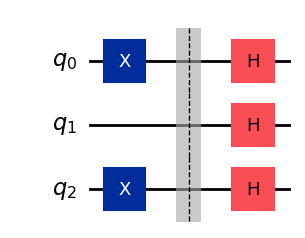

In [4]:
n = 3
j_string = '101'
qc = QuantumCircuit(n)

# Qiskit qubit 0 is the rightmost bit in the usual |q2 q1 q0> label.
for q, bit in enumerate(reversed(j_string)):
    if bit == '1':
        qc.x(q)

qc.barrier()
qc.h(range(n))
qc.draw(output='mpl')

## What happens when $|j\rangle=|0^n\rangle$?

If $j=0^n$, then

$$H^{\otimes n}|0^n\rangle = |+^n\rangle
= \frac{1}{\sqrt{2^n}}\sum_{k\in\{0,1\}^n}|k\rangle.$$

For $n=3$:

$$H^{\otimes 3}|000\rangle
= \frac{|000\rangle+|001\rangle+|010\rangle+|011\rangle+|100\rangle+|101\rangle+|110\rangle+|111\rangle}{\sqrt8}.$$

This is the uniform superposition over all 3-bit strings.

## Why $H^{\otimes n}|j\rangle$ has phases $(-1)^{j\cdot k}$

Let

$$|j\rangle = |j_{n-1}\cdots j_0\rangle.$$

Recall that for a single qubit with state $|x\rangle$,

$$H|x\rangle = \frac{1}{\sqrt2}\sum_{y\in\{0,1\}}(-1)^{xy}|y\rangle,$$

Apply one Hadamard to each qubit:

$$H^{\otimes n}|j_{n-1}\cdots j_0\rangle
= \bigotimes_{r=0}^{n-1}\left(\frac{1}{\sqrt2}\sum_{k_r\in\{0,1\}}(-1)^{j_r k_r}|k_r\rangle\right).$$

Multiplying the $n$ sums gives every possible output bit string $k$ once.

## The compact expression

The normalization multiplies to $2^{-n/2}$.

The signs multiply as

$$\prod_{r=0}^{n-1}(-1)^{j_rk_r} = (-1)^{\sum_r j_rk_r} = (-1)^{j\cdot k},$$

because only the parity of the exponent matters.

Therefore

$$\boxed{H^{\otimes n}|j\rangle = \frac{1}{\sqrt{2^n}}\sum_{k\in\{0,1\}^n}(-1)^{j\cdot k}|k\rangle.}$$

In [5]:
n = 3
for j in range(3):
    qc = QuantumCircuit(n)
    for q, bit in enumerate(reversed(bits(j, n))):
        if bit == '1':
            qc.x(q)
    qc.h(range(n))
    state = Statevector.from_instruction(qc)
    phases = []
    for k, amp in enumerate(state.data):
        sign = '+' if np.real_if_close(amp).real > 0 else '-'
        phases.append(f'{sign}|{bits(k,n)}>')
    print(f'H^⊗{n}|{bits(j,n)}> = (1/sqrt(8)) ' + ' '.join(phases))

H^⊗3|000> = (1/sqrt(8)) +|000> +|001> +|010> +|011> +|100> +|101> +|110> +|111>
H^⊗3|001> = (1/sqrt(8)) +|000> -|001> +|010> -|011> +|100> -|101> +|110> -|111>
H^⊗3|010> = (1/sqrt(8)) +|000> +|001> -|010> -|011> +|100> +|101> -|110> -|111>


# Simon's Algorithm

## The promise problem

We are given black-box access to a function

$$f:\{0,1\}^n\rightarrow\{0,1\}^n.$$

Promise: there is a hidden string $s$ such that

$$f(x)=f(y) \quad \text{if and only if} \quad y=x\oplus s.$$

If $s=0^n$, then $f$ is one-to-one. If $s\ne0^n$, then $f$ is two-to-one, pairing $x$ with $x\oplus s$.

## A tiny example

Let $n=3$ and suppose

$$s=110.$$

Then $x$ and $x\oplus110$ always share the same output:

$$f(000) = f(110),$$
$$f(001) = f(111),$$
$$f(010) = f(100),$$
$$f(011) = f(101).$$

The challenge: discover $s$ using as few oracle calls as possible.

In [6]:
n = 3
s = int('110', 2)
seen = set()
for x in range(2**n):
    if x in seen:
        continue
    pair = x ^ s
    seen |= {x, pair}
    print(f'{bits(x,n)} pairs with {bits(pair,n)}')

000 pairs with 110
001 pairs with 111
010 pairs with 100
011 pairs with 101


## Classical query cost

A classical randomized algorithm can query inputs one at a time:

$$x \longmapsto f(x).$$

If it ever finds a collision,

$$f(x)=f(y),$$

then the promise tells us

$$s=x\oplus y.$$

The hard part is finding the first collision. There are $2^n$ possible inputs, and the matching partner of a chosen $x$ is only one special string, $x\oplus s$.

So random classical sampling usually needs many queries before two sampled inputs land in the same hidden pair. More precisely, the expected scale is about $2^{n/2}$ queries (c.f. the birthday problem).

# How can we do better?

We will use Simon's (quantum) algorithm and a quantum oracle to get the job done!

## Oracles

An oracle is a black-box way to use a function.

You are allowed to give it an input $x$ and receive $f(x)$, but you are not allowed to open the box and inspect the rule for $f$.

In algorithm analysis, we count how many times we query the oracle.

For Simon's problem, the oracle hides the string $s$. The whole question is: how many queries do we need before we can infer $s$?

## Quantum Oracle

A quantum oracle is the circuit version of the same black box.

The new requirement is that it must be a valid quantum operation, so it has to be reversible/unitary.

A tempting map would be

$$|x\rangle \mapsto |f(x)\rangle,$$

but this is not reversible when two different inputs have the same output. Simon's function is explicitly two-to-one when $s\ne0$.

## Let's use two registers

A register is just a named bundle of qubits. An $n$-qubit register stores an $n$-bit string such as $|101\rangle$.

To make the function reversible, the quantum oracle keeps the input $x$ and writes the function value into a second register:

$$U_f|x\rangle|y\rangle = |x\rangle|y\oplus f(x)\rangle.$$

If the second register starts at $|0^n\rangle$, then

$$U_f|x\rangle|0^n\rangle = |x\rangle|f(x)\rangle.$$

The second register is often called the output register because it holds the value of $f(x)$ after the oracle call.

## Why this works on a superposition

Because quantum gates are linear, one oracle call acts on every branch of a superposition at once:

$$\frac{1}{\sqrt{2^n}}\sum_x |x\rangle|0^n\rangle
\xrightarrow{U_f}
\frac{1}{\sqrt{2^n}}\sum_x |x\rangle|f(x)\rangle.$$

This does not mean we can read every $f(x)$ from one measurement because measurement collapses the state onto a single classical state.

The advantage comes from the next step: interference makes the hidden relationship between paired inputs visible.

## Simon circuit skeleton

Start both registers at zero:

$$|0^n\rangle|0^n\rangle.$$

Put the input register into a uniform superposition:

$$\xrightarrow{H^{\otimes n}\otimes I} \frac{1}{\sqrt{2^n}}\sum_x |x\rangle|0^n\rangle.$$

Query the quantum oracle:

$$\xrightarrow{U_f} \frac{1}{\sqrt{2^n}}\sum_x |x\rangle|f(x)\rangle.$$

For analysis, imagine measuring the output register. If the measured value is $f(x)$, the promise says there are exactly two compatible inputs: $x$ and $x\oplus s$.

So the input register is left in the hidden-pair state

$$\frac{|x\rangle+|x\oplus s\rangle}{\sqrt2}.$$

## The key interference step

Now apply $H^{\otimes n}$ to the first register:

$$H^{\otimes n}\frac{|x\rangle+|x\oplus s\rangle}{\sqrt2}$$

$$= \frac{1}{\sqrt{2^{n+1}}}\sum_y\left[(-1)^{x\cdot y}+(-1)^{(x\oplus s)\cdot y}\right]|y\rangle.$$

Because

$$(x\oplus s)\cdot y = x\cdot y \oplus s\cdot y,$$

we get constructive interference only when

$$s\cdot y=0.$$

## What the measurement gives

Every run produces a random $y$ satisfying

$$s\cdot y=0 \pmod 2.$$

For $n=3$ and $s=110$, the allowed outputs are

$$000,001,110,111.$$

Repeat until we have enough independent equations to solve for $s$.

In [7]:
s_bits = '110'
allowed = [bits(y, 3) for y in range(8) if dot_mod2(s_bits, bits(y, 3)) == 0]
print('Allowed y values for s = 110:', allowed)

Allowed y values for s = 110: ['000', '001', '110', '111']


## A Simon oracle in Qiskit

For a small demo, define a promised function by assigning the same label to $x$ and $x\oplus s$.

We build the oracle as a reversible permutation:

$$|x\rangle|y\rangle \mapsto |x\rangle|y\oplus f(x)\rangle.$$

This is not how we would synthesize a large oracle by hand, but it is perfect for seeing the algorithm's state evolution.

In [8]:
def simon_function_table(n, s):
    labels = {}
    next_label = 0
    for x in range(2**n):
        if x in labels:
            continue
        pair = x ^ s
        labels[x] = next_label
        labels[pair] = next_label
        next_label += 1
    return labels

def simon_oracle_gate(n, s):
    f = simon_function_table(n, s)
    dim = 2 ** (2*n)
    U = np.zeros((dim, dim), dtype=complex)
    for basis in range(dim):
        x = basis & ((1 << n) - 1)
        y = basis >> n
        y_out = y ^ f[x]
        out = x | (y_out << n)
        U[out, basis] = 1
    return UnitaryGate(U, label=f'U_f, s={bits(s,n)}'), f

oracle, f = simon_oracle_gate(3, int('110', 2))
for x in range(8):
    print(f'f({bits(x,3)}) = {bits(f[x],3)}')

f(000) = 000
f(001) = 001
f(010) = 010
f(011) = 011
f(100) = 010
f(101) = 011
f(110) = 000
f(111) = 001


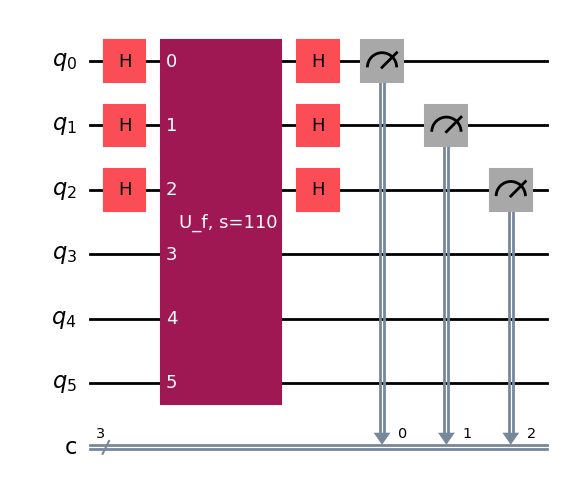

In [9]:
n = 3
s = int('110', 2)
oracle, _ = simon_oracle_gate(n, s)

qc = QuantumCircuit(2*n, n)
qc.h(range(n))
qc.append(oracle, range(2*n))
qc.h(range(n))
qc.measure(range(n), range(n))
qc.draw(output='mpl')

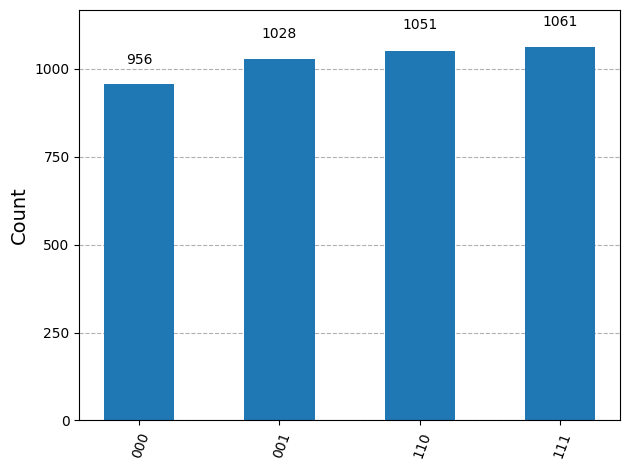

In [10]:
state_circuit = QuantumCircuit(2*n)
state_circuit.h(range(n))
state_circuit.append(oracle, range(2*n))
state_circuit.h(range(n))
state = Statevector.from_instruction(state_circuit)
counts = state.sample_counts(shots=4096, qargs=range(n))
plot_histogram(counts)

In [11]:
print(counts)
print('All sampled y satisfy s · y = 0:', all(dot_mod2(bits(s,n), y) == 0 for y in counts))

{np.str_('000'): np.int64(956), np.str_('001'): np.int64(1028), np.str_('110'): np.int64(1051), np.str_('111'): np.int64(1061)}
All sampled y satisfy s · y = 0: True


## Classical post-processing

After the quantum circuit, each measurement gives a string $y$ with one guaranteed property:

$$s\cdot y=0 \pmod 2.$$

Think of this as one linear equation whose unknowns are the bits of $s$.

Example with three unknown bits:

$$s=s_2s_1s_0.$$

If we measure $y=001$, then

$$s\cdot001=s_0=0.$$

If we measure $y=110$, then

$$s\cdot110=s_2\oplus s_1=0,$$

so $s_2=s_1$.

A few independent measurements give enough equations to narrow down the nonzero $s$. For the example above, the equations force

$$s=110.$$

In [12]:
def candidate_secrets(measured_ys, n):
    candidates = []
    for s_candidate in range(1, 2**n):
        sb = bits(s_candidate, n)
        if all(dot_mod2(sb, y) == 0 for y in measured_ys):
            candidates.append(sb)
    return candidates

sample_ys = [y for y, c in counts.items() if y != '000'][:2]
print('Using equations from y =', sample_ys)
print('Candidate hidden strings:', candidate_secrets(sample_ys, n))

Using equations from y = [np.str_('001'), np.str_('110')]
Candidate hidden strings: ['110']


## Why Simon's Algorithm Matters

The promise problem itself is not a common practical task. However, Simon's algorithm was one of the first clear signs that quantum computation could give an exponential query advantage.

It follows a simple workflow:

1. Create a superposition over all inputs
2. Query the oracle once
3. Use interference to reveal the desired structure
4. Repeat until you can finish with classical linear algebra

In the promise problem, the hidden structure is an XOR mask $s$, and Hadamards are enough to reveal it.

In Shor's algorithm, the hidden structure is a period $r$, and the Quantum Fourier Transform is the tool that reveals it.